In [ ]:
%pip install PyWavelets

In [1]:
import cv2
import pywt
import numpy as np
import matplotlib.pyplot as plt

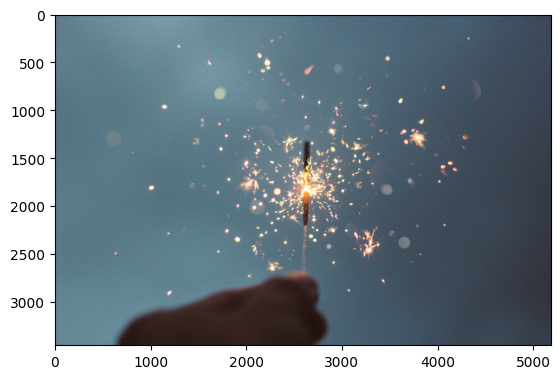

In [2]:
img_path = "cristian-escobar-abkEAOjnY0s-unsplash.jpg"

img = cv2.imread(img_path)
img = img[:, :, ::-1]
plt.imshow(img)

In [3]:
target_width = 2592
coef_ratio = img.shape[1] / img.shape[0]
target_height = int(target_width / coef_ratio)
print(coef_ratio)
print(target_height)

1.5
1728


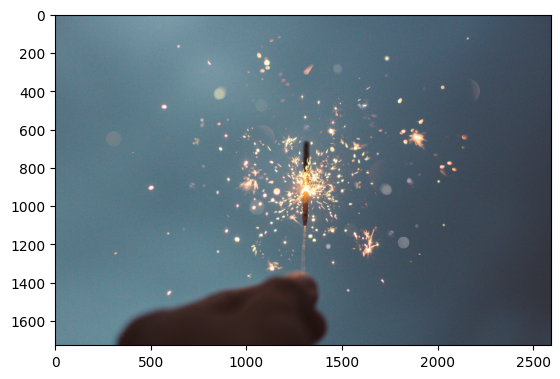

In [7]:
img_resz = cv2.resize(img, (target_width, target_height), interpolation=cv2.INTER_AREA)
plt.imshow(img_resz)

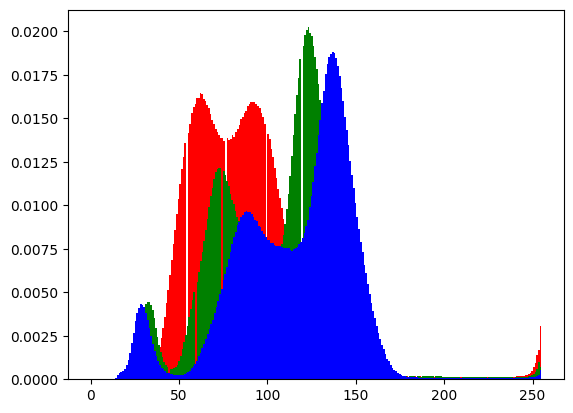

In [8]:
hist_r = plt.hist(img_resz[:, :, 0].ravel(), bins=256, density=True, color='r')
hist_g = plt.hist(img_resz[:, :, 1].ravel(), bins=256, density=True, color='g')
hist_b = plt.hist(img_resz[:, :, 2].ravel(), bins=256, density=True, color='b')

plt.show()

In [11]:
print(round(max(hist_r[0].max(), hist_g[0].max(), hist_b[0].max()), 4))

0.0202


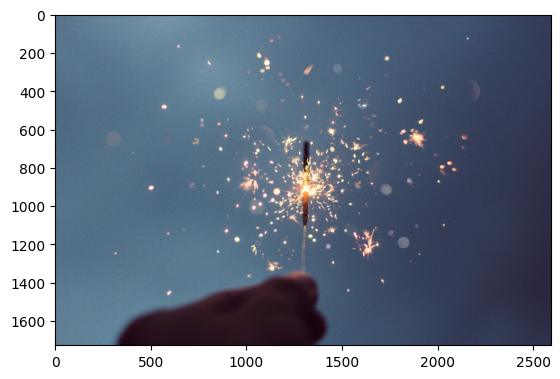

In [12]:
img_norm = img_resz.copy()

for i in range(3):
    chan = img_resz[:, :, i]
    min_, max_ = chan.min(), chan.max()
    chan = (chan - min_) / (max_ - min_) * 255
    img_norm[:, :, i] = chan.astype(np.uint8)

plt.imshow(img_norm)

In [13]:
row, col = 832, 1328
img_norm[row, col]

array([234, 196, 136], dtype=uint8)

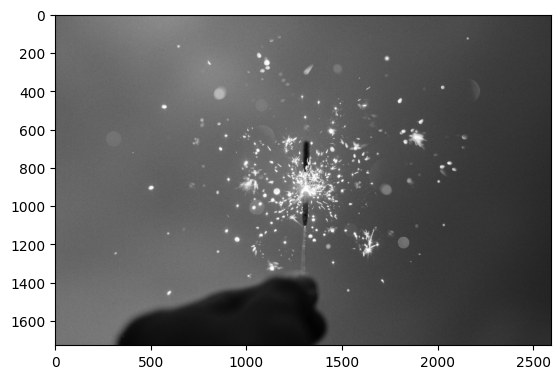

In [24]:
gray = cv2.cvtColor(img_norm, cv2.COLOR_RGB2GRAY)
plt.imshow(gray, 'gray')

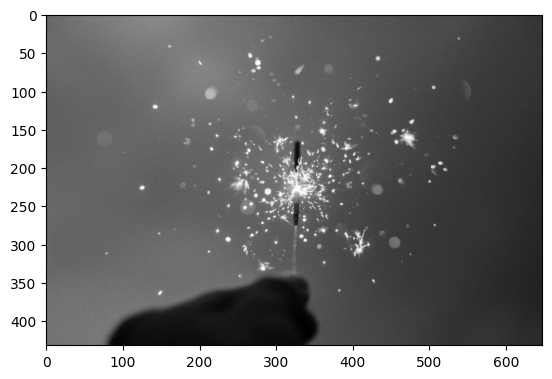

In [26]:
cA, _ = pywt.dwt2(gray, 'haar')
cA2, _ = pywt.dwt2(cA, 'haar')
plt.imshow(cA2, 'gray')

In [27]:
thr = 80
(np.abs(cA2) < thr).sum()

np.int64(1960)